# Library imports

In [1]:
import os
import glob
import numpy as np
import soundfile as sf
import polars as pl
import librosa
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['figure.dpi'] = 100

# Preprocessing

Lectura de archivos de audio

Convención de etiquetas:
- PD → label = 1 (clase positiva: enfermedad presente)
- HD → label = 0 (clase negativa: sano)

In [2]:
BASE_PATH = "data"

files_pd = sorted(glob.glob(os.path.join(BASE_PATH, "PD", "*.wav")))
files_hd = sorted(glob.glob(os.path.join(BASE_PATH, "HC", "*.wav")))

df_metadata = pl.DataFrame({
    "filepath": files_pd + files_hd,
    "filename": [os.path.basename(f) for f in files_pd + files_hd],
    "label": [1] * len(files_pd) + [0] * len(files_hd),
    "label_name": ["PD"] * len(files_pd) + ["HD"] * len(files_hd)
})

print(f"Parkinson files: {len(files_pd)}")
print(f"Healthy files: {len(files_hd)}")

Parkinson files: 50
Healthy files: 50


## Carga de Señales de Audio (Formas de Onda Crudas)

### Señal digital de audio

Un archivo de audio digital contiene una secuencia de valores de amplitud muestreados a una frecuencia fija (*sample rate*, $sr$):

$$x[n] = x\left(\frac{n}{sr}\right), \quad n = 0, 1, \ldots, N-1$$

donde $N$ es el total de muestras y la duración es $T = N / sr$.

### Decisión de diseño: $sr = 16{,}000$ Hz

Remuestreamos todos los audios a 16 kHz porque:

1. **Teorema de Nyquist-Shannon**: La voz humana relevante está bajo 8 kHz, por lo que $sr \geq 2 \times 8000 = 16000$ es suficiente.
2. **Eficiencia**: Menos muestras que 44.1 kHz sin perder información vocal relevante.


## Preprocesamiento Mínimo

Cuando trabajamos con formas de onda crudas como entrada a modelos de deep learning, el objetivo es **preservar la mayor cantidad de información posible** y dejar que el modelo aprenda sus propias representaciones (Ravanelli & Bengio, 2018).

Por eso, el preprocesamiento se limita a dos operaciones:

### 1. Recorte de silencios (*trimming*)

Elimina segmentos al inicio y final donde la energía está por debajo de un umbral. Se calcula la energía en dB por ventanas:

$$E_{dB}[m] = 20 \times \log_{10}(\text{RMS}[m])$$

donde $\text{RMS}[m] = \sqrt{\frac{1}{K} \sum_{k} x[k]^2}$ es la energía de la ventana $m$.

Se recortan las ventanas donde $E_{dB}[m] < E_{dB}^{max} - \text{top\_db}$. Usamos $\text{top\_db} = 20$, valor estándar en la literatura.

**¿Por qué?** Los silencios iniciales/finales no contienen información sobre la condición del paciente y añaden variabilidad no informativa.

### 2. Normalización de amplitud (*peak normalization*)

Escala la señal para que su valor absoluto máximo sea un valor objetivo:

$$\hat{x}[n] = 0.95 \times \frac{x[n]}{\max(|x[n]|)}$$

**¿Por qué?** Diferentes micrófonos y distancias de grabación producen volúmenes distintos. Sin normalización, el modelo podría aprender a clasificar por volumen en lugar de por patrones vocales.

### Orden del pipeline

1. **Primero** recortar silencios → eliminamos muestras no informativas.
2. **Después** normalizar → la normalización se calcula solo sobre la voz activa.

In [3]:
TARGET_SR = 16000

waveforms = []
durations = []

for i, filepath in enumerate(df_metadata["filepath"].to_list()):
    wf, sr_orig = sf.read(filepath)

    # ----------------------------------------------
    # CONVERTIR A MONO SI EL AUDIO ESTA EN STEREO
    # ----------------------------------------------
    if wf.ndim > 1:
        wf = wf.mean(axis=1)

    # ----------------------------------------------
    # REMUESTREAR A 16 kHz SI ES NECESARIO
    # ----------------------------------------------
    if sr_orig != TARGET_SR:
        wf = librosa.resample(wf, orig_sr=sr_orig, target_sr=TARGET_SR)
        wf = librosa.resample(wf, orig_sr=sr_orig, target_sr=TARGET_SR)

    waveforms.append(wf)
    durations.append(len(wf) / TARGET_SR)

df_metadata = df_metadata.with_columns(
    pl.Series("duration_s", durations)
)

print(f"{len(waveforms)} archivos cargados a {TARGET_SR} Hz")
print(f"\nEstadísticas de duración (segundos):")
print(df_metadata.group_by("label_name").agg([
    pl.col("duration_s").mean().alias("media"),
    pl.col("duration_s").min().alias("min"),
    pl.col("duration_s").max().alias("max")
]))

100 archivos cargados a 16000 Hz

Estadísticas de duración (segundos):
shape: (2, 4)
┌────────────┬──────────┬───────────┬───────────┐
│ label_name ┆ media    ┆ min       ┆ max       │
│ ---        ┆ ---      ┆ ---       ┆ ---       │
│ str        ┆ f64      ┆ f64       ┆ f64       │
╞════════════╪══════════╪═══════════╪═══════════╡
│ PD         ┆ 1.70151  ┆ 0.5041875 ┆ 3.817875  │
│ HD         ┆ 1.479606 ┆ 0.610375  ┆ 3.0748125 │
└────────────┴──────────┴───────────┴───────────┘


In [4]:
def preprocess_waveform(waveform, target_peak=0.95, top_db=20, eps=1e-8):
    # ----------------------------------------------
    # PASO 1: NORMALIZACION PEAK
    # ----------------------------------------------
    peak = np.max(np.abs(waveform))
    if peak > eps:
        wf_normalized = target_peak * (waveform / peak)
    else:
        wf_normalized = waveform

    # ----------------------------------------------
    # PASO 2: RECORTE DE SILENCIOS
    # ----------------------------------------------
    wf_trimmed, _ = librosa.effects.trim(wf_normalized, top_db=top_db)

    return wf_trimmed

# ----------------------------------------------
# REAPLICAR A TODOS LOS AUDIOS
# ----------------------------------------------
waveforms_processed = []
durations_processed = []

for wf in waveforms:
    wf_proc = preprocess_waveform(wf)
    waveforms_processed.append(wf_proc)
    durations_processed.append(len(wf_proc) / TARGET_SR)

df_metadata = df_metadata.with_columns(
    pl.Series("duration_s_processed", durations_processed)
)

print("Preprocesamiento completado (orden corregido)")
print(f"\nComparación de duraciones (segundos):")
print(df_metadata.group_by("label_name").agg([
    pl.col("duration_s").mean().alias("original_media"),
    pl.col("duration_s_processed").mean().alias("procesada_media"),
]))

Preprocesamiento completado (orden corregido)

Comparación de duraciones (segundos):
shape: (2, 3)
┌────────────┬────────────────┬─────────────────┐
│ label_name ┆ original_media ┆ procesada_media │
│ ---        ┆ ---            ┆ ---             │
│ str        ┆ f64            ┆ f64             │
╞════════════╪════════════════╪═════════════════╡
│ PD         ┆ 1.70151        ┆ 1.695519        │
│ HD         ┆ 1.479606       ┆ 1.477685        │
└────────────┴────────────────┴─────────────────┘


## Visualización de recorte de sonido

Persona Sana (HD):


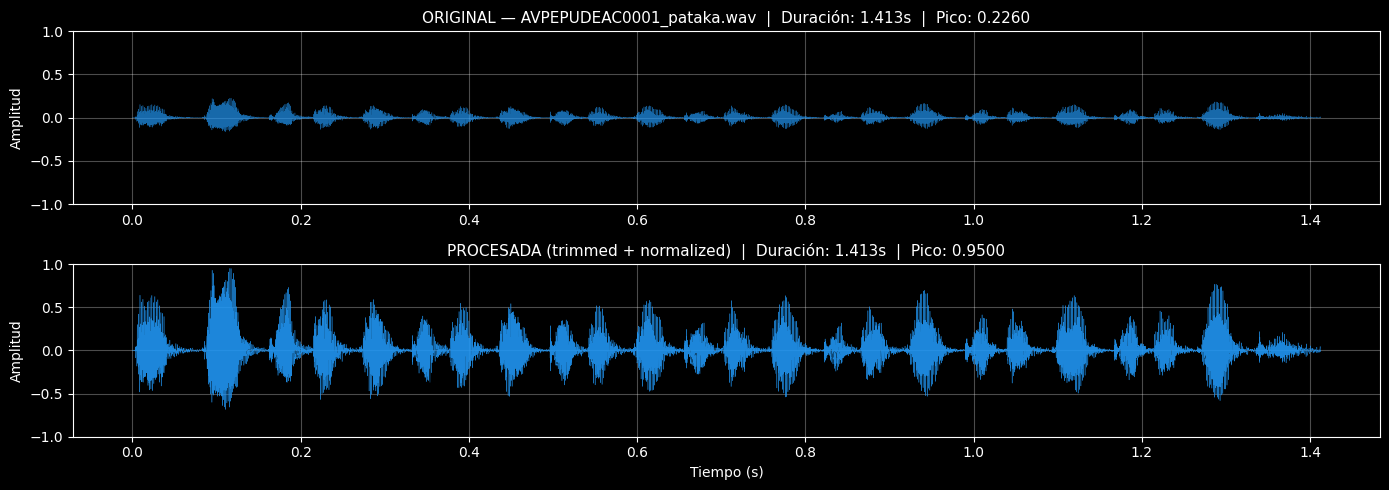


Paciente con Parkinson (PD):


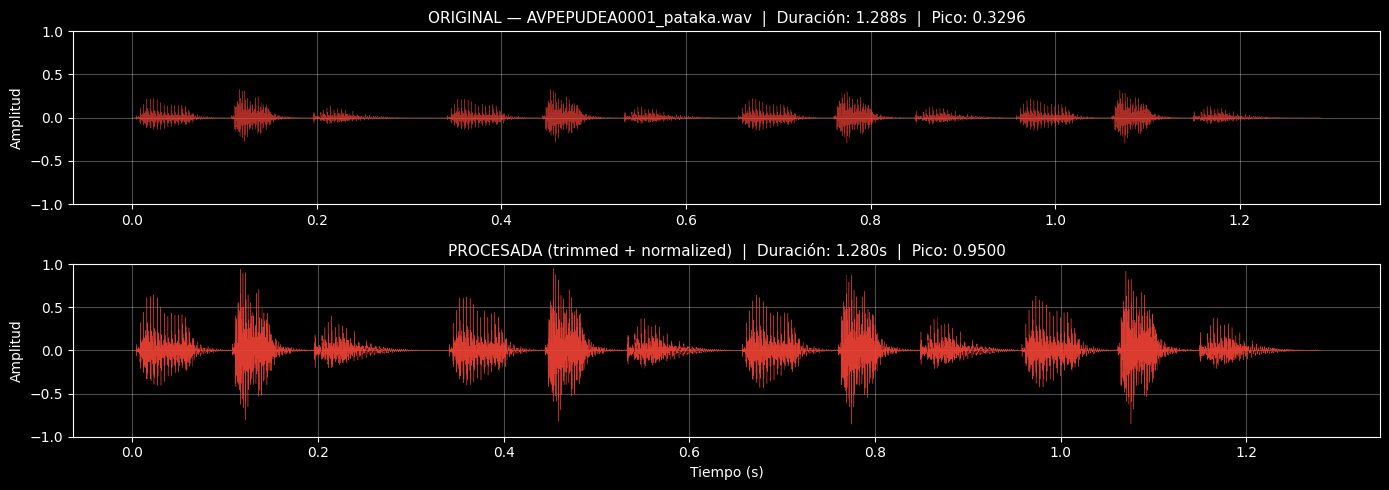

In [5]:
def plot_before_after(idx, label_name):
    wf_orig = waveforms[idx]
    wf_proc = waveforms_processed[idx]
    t_orig = np.arange(len(wf_orig)) / TARGET_SR
    t_proc = np.arange(len(wf_proc)) / TARGET_SR

    fig, axes = plt.subplots(2, 1, figsize=(14, 5))

    color = "#2196F3" if label_name == "HD" else "#F44336"

    # ----------------------------------------------
    # SENAL ORIGINAL
    # ----------------------------------------------
    axes[0].plot(t_orig, wf_orig, color=color, linewidth=0.3, alpha=0.7)
    axes[0].set_title(f"ORIGINAL — {df_metadata['filename'][idx]}  |  "
                      f"Duración: {len(wf_orig)/TARGET_SR:.3f}s  |  "
                      f"Pico: {np.max(np.abs(wf_orig)):.4f}", fontsize=11)
    axes[0].set_ylabel("Amplitud")
    axes[0].set_ylim([-1, 1])
    axes[0].grid(True, alpha=0.3)

    # ----------------------------------------------
    # SENAL PROCESADA
    # ----------------------------------------------
    axes[1].plot(t_proc, wf_proc, color=color, linewidth=0.3, alpha=0.9)
    axes[1].set_title(f"PROCESADA (trimmed + normalized)  |  "
                      f"Duración: {len(wf_proc)/TARGET_SR:.3f}s  |  "
                      f"Pico: {np.max(np.abs(wf_proc)):.4f}", fontsize=11)
    axes[1].set_ylabel("Amplitud")
    axes[1].set_xlabel("Tiempo (s)")
    axes[1].set_ylim([-1, 1])
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ----------------------------------------------
# UN EJEMPLO ALEATORIO PARA CADA CLASE
# ----------------------------------------------
idx_hd = df_metadata.filter(pl.col("label_name") == "HD").row_nr(0) if hasattr(df_metadata, 'row_nr') else \
         df_metadata["label_name"].to_list().index("HD")
idx_pd = df_metadata["label_name"].to_list().index("PD")

print("Persona Sana (HD):")
plot_before_after(idx_hd, "HD")

print("\nPaciente con Parkinson (PD):")
plot_before_after(idx_pd, "PD")

## Unificación de Longitudes (Padding / Truncating)

### ¿Por qué es necesario?

PyTorch trabaja con **tensores de tamaño fijo** dentro de cada batch. Si una señal tiene 20,000 muestras y otra 50,000, no pueden agruparse en un mismo tensor. Necesitamos que todas tengan la misma longitud $L$.

### Estrategia

Dada una longitud objetivo $L$:

- **Si la señal es más corta** ($N < L$): Se rellena con ceros al final (*zero-padding*). Matemáticamente:

$$x_{pad}[n] = \begin{cases} x[n] & \text{si } n < N \\ 0 & \text{si } N \leq n < L \end{cases}$$

- **Si la señal es más larga** ($N > L$): Se recorta desde el inicio (*truncating*), conservando los primeros $L$ valores:

$$x_{trunc}[n] = x[n], \quad n = 0, 1, \ldots, L-1$$

### ¿Cómo elegir $L$?

Opciones comunes:
- **Duración máxima**: No se pierde información, pero genera mucho padding en señales cortas.
- **Percentil 95**: Buen balance — se preserva la mayoría de señales completas y se limita el padding excesivo.
- **Duración media**: Compromiso agresivo — muchas señales se recortan.

Analizaremos la distribución de duraciones para tomar una decisión informada.

Distribución de duraciones procesadas (segundos):
  Percentil 50 (mediana): 1.470s  →  23,512 muestras
  Percentil 75:           2.023s  →  32,369 muestras
  Percentil 90:           2.463s  →  39,401 muestras
  Percentil 95:           2.713s  →  43,401 muestras
  Máximo:                 3.818s  →  61,086 muestras


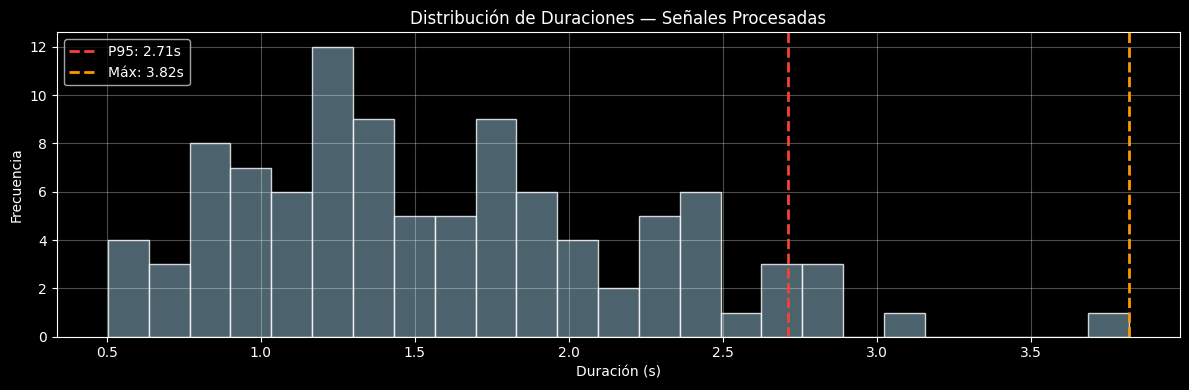

In [6]:
durations_arr = np.array(durations_processed)

p50 = np.percentile(durations_arr, 50)
p75 = np.percentile(durations_arr, 75)
p90 = np.percentile(durations_arr, 90)
p95 = np.percentile(durations_arr, 95)
d_max = np.max(durations_arr)

print("Distribución de duraciones procesadas (segundos):")
print(f"  Percentil 50 (mediana): {p50:.3f}s  →  {int(p50 * TARGET_SR):,} muestras")
print(f"  Percentil 75:           {p75:.3f}s  →  {int(p75 * TARGET_SR):,} muestras")
print(f"  Percentil 90:           {p90:.3f}s  →  {int(p90 * TARGET_SR):,} muestras")
print(f"  Percentil 95:           {p95:.3f}s  →  {int(p95 * TARGET_SR):,} muestras")
print(f"  Máximo:                 {d_max:.3f}s  →  {int(d_max * TARGET_SR):,} muestras")

plt.figure(figsize=(12, 4))
plt.hist(durations_arr, bins=25, color="#607D8B", edgecolor="white", alpha=0.8)
plt.axvline(p95, color="#F44336", linestyle="--", linewidth=2, label=f"P95: {p95:.2f}s")
plt.axvline(d_max, color="#FF9800", linestyle="--", linewidth=2, label=f"Máx: {d_max:.2f}s")
plt.xlabel("Duración (s)")
plt.ylabel("Frecuencia")
plt.title("Distribución de Duraciones — Señales Procesadas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Aplicación de Padding / Truncating

Se unifica la longitud de todas las señales a **$L = 120{,}000$ muestras (7.5 segundos)**, correspondiente al percentil 95 de las duraciones.

- El 95% de las señales se preservan completas (solo se les agrega ceros al final).
- El 5% restante se recorta, perdiendo información mínima al final de la grabación.
- El *zero-padding* no introduce artefactos en la señal, simplemente extiende con silencio.

In [7]:
TARGET_LENGTH = 120000  # 7.5 segundos a 16 kHz

def pad_or_truncate(waveform, target_length):
    n = len(waveform)
    if n < target_length:

        # ----------------------------------------------
        # PADDING CON CEROS
        # ----------------------------------------------
        padded = np.zeros(target_length)
        padded[:n] = waveform
        return padded
    else:
        # ----------------------------------------------
        # TRUNCAR
        # ----------------------------------------------
        return waveform[:target_length]

# Aplicar a todas las señales
waveforms_fixed = [pad_or_truncate(wf, TARGET_LENGTH) for wf in waveforms_processed]

# Verificar
n_padded = sum(1 for wf in waveforms_processed if len(wf) < TARGET_LENGTH)
n_truncated = sum(1 for wf in waveforms_processed if len(wf) > TARGET_LENGTH)
n_exact = sum(1 for wf in waveforms_processed if len(wf) == TARGET_LENGTH)

print(f"✅ Todas las señales unificadas a {TARGET_LENGTH:,} muestras ({TARGET_LENGTH/TARGET_SR}s)")
print(f"\n  Señales con padding (eran más cortas):  {n_padded}")
print(f"  Señales truncadas (eran más largas):     {n_truncated}")
print(f"  Señales sin cambio (longitud exacta):    {n_exact}")
print(f"\n  Shape final de cada señal: {waveforms_fixed[0].shape}")

✅ Todas las señales unificadas a 120,000 muestras (7.5s)

  Señales con padding (eran más cortas):  100
  Señales truncadas (eran más largas):     0
  Señales sin cambio (longitud exacta):    0

  Shape final de cada señal: (120000,)


## División del Dataset (Train / Validation / Test)

### ¿Por qué dividir antes de entrenar?

Es fundamental separar los datos **antes** de cualquier paso de modelado para evitar *data leakage* (fuga de información). Si el modelo ve datos de test durante el entrenamiento, las métricas de evaluación no reflejarán su capacidad de generalización real.

### Estrategia

- **Train (70%)**: Para entrenar los modelos.
- **Validation (15%)**: Para ajustar hiperparámetros y monitorear sobreajuste durante el entrenamiento.
- **Test (15%)**: Evaluación final. Solo se usa una vez.

### Estratificación

Usamos **estratificación por clase** para garantizar que la proporción HD/PD se mantenga en cada partición. Con un dataset de 100 archivos (50+50), esto es especialmente importante para evitar desbalances accidentales en particiones pequeñas.

### Reproducibilidad

Se fija una semilla aleatoria (`random_state=42`) para que la división sea exactamente replicable.

In [8]:
RANDOM_STATE = 42

labels = df_metadata["label"].to_numpy()
indices = np.arange(len(waveforms_fixed))

# ----------------------------------------------
# SEPARAR TESTS (15%)
# ----------------------------------------------
idx_train_val, idx_test, y_train_val, y_test = train_test_split(
    indices, labels,
    test_size=0.15,
    stratify=labels,
    random_state=RANDOM_STATE
)

# ----------------------------------------------
# SEPARAR TRAING (70%) Y VALIDATION (15%) DEL RESTANTE (85%)
# ----------------------------------------------
idx_train, idx_val, y_train, y_val = train_test_split(
    idx_train_val, y_train_val,
    test_size=0.176,  # 0.176 de 85% ≈ 15% del total
    stratify=y_train_val,
    random_state=RANDOM_STATE
)

print("División del dataset completada")
print(f"\n{'Partición':<12} {'Total':>6} {'HD (0)':>8} {'PD (1)':>8}")
print("-" * 36)
for name, y in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    n_hd = np.sum(y == 0)
    n_pd = np.sum(y == 1)
    print(f"{name:<12} {len(y):>6} {n_hd:>8} {n_pd:>8}")
print("-" * 36)
print(f"{'Total':<12} {len(labels):>6} {np.sum(labels==0):>8} {np.sum(labels==1):>8}")

División del dataset completada

Partición     Total   HD (0)   PD (1)
------------------------------------
Train            70       35       35
Validation       15        7        8
Test             15        8        7
------------------------------------
Total           100       50       50


## Dataset y DataLoader de PyTorch

### ¿Qué es un Dataset?

En PyTorch, un `Dataset` es una clase que encapsula los datos y permite acceder a cada muestra individualmente mediante un índice. Debe implementar dos métodos:

- `__len__()`: Retorna el número total de muestras.
- `__getitem__(idx)`: Retorna la muestra y su etiqueta en el índice `idx`.

### ¿Qué es un DataLoader?

El `DataLoader` envuelve al `Dataset` y se encarga de:

- **Crear batches**: Agrupa $B$ muestras en un tensor de forma $(B, 1, L)$.
- **Mezclar los datos** (*shuffle*): Aleatoriza el orden en cada época de entrenamiento.
- **Paralelizar la carga**: Usa múltiples workers para cargar datos en segundo plano.

### ¿Por qué forma $(B, 1, L)$?

Las CNNs 1D en PyTorch esperan tensores con la dimensión de canales explícita:

$$\text{input shape} = (B, C, L)$$

donde $B$ = batch size, $C$ = canales (1 para audio mono), $L$ = longitud de la señal.

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader

class ParkinsonWaveformDataset(Dataset):
    def __init__(self, waveforms, labels, indices):
        self.waveforms = [waveforms[i] for i in indices]
        self.labels = [labels[i] for i in indices]

    def __len__(self):
        return len(self.waveforms)

    def __getitem__(self, idx):
        # ----------------------------------------------
        # FORMA DE ONDA: (L,) → (1, L) PARA EL CANAL DE AUDIO
        # ----------------------------------------------
        x = torch.tensor(self.waveforms[idx], dtype=torch.float32).unsqueeze(0)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y

# ----------------------------------------------
# CREAR LOS DATASETS
# ----------------------------------------------
train_dataset = ParkinsonWaveformDataset(waveforms_fixed, labels, idx_train)
val_dataset   = ParkinsonWaveformDataset(waveforms_fixed, labels, idx_val)
test_dataset  = ParkinsonWaveformDataset(waveforms_fixed, labels, idx_test)

# ----------------------------------------------
# CREACION DE DATALOADERS
# ----------------------------------------------
BATCH_SIZE = 8

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

x_batch, y_batch = next(iter(train_loader))
print(f"DataLoaders creados correctamente")
print(f"\n  Train:      {len(train_dataset)} muestras  →  {len(train_loader)} batches")
print(f"  Validation: {len(val_dataset)} muestras  →  {len(val_loader)} batches")
print(f"  Test:       {len(test_dataset)} muestras  →  {len(test_loader)} batches")
print(f"\n  Shape de un batch (x): {x_batch.shape}  →  (batch, canales, longitud)")
print(f"  Shape de un batch (y): {y_batch.shape}  →  (batch,)")
print(f"  Etiquetas del batch:   {y_batch.tolist()}")

DataLoaders creados correctamente

  Train:      70 muestras  →  9 batches
  Validation: 15 muestras  →  2 batches
  Test:       15 muestras  →  2 batches

  Shape de un batch (x): torch.Size([8, 1, 120000])  →  (batch, canales, longitud)
  Shape de un batch (y): torch.Size([8])  →  (batch,)
  Etiquetas del batch:   [0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0]


# Arquitecturas

## Arquitectura 1: Red Neuronal Convolucional 1D (CNN 1D)

### ¿Por qué CNN 1D para audio crudo?

Una CNN 1D aplica filtros que se deslizan a lo largo del eje temporal de la señal. Cada filtro aprende a detectar un patrón local específico (un "motivo" temporal). Esto es análogo a cómo una CNN 2D detecta bordes o texturas en imágenes, pero en una sola dimensión.

### ¿Qué puede aprender de señales de Parkinson?

- **Capas iniciales**: Patrones de baja abstracción como oscilaciones de frecuencia fundamental, variaciones rápidas de amplitud (shimmer/jitter).
- **Capas profundas**: Combinaciones de patrones que representan irregularidades articulatorias, temblor vocal, o cambios de ritmo característicos de la enfermedad.

### Operación de convolución 1D

Dado un filtro $w$ de tamaño $k$ y una señal de entrada $x$, la salida en la posición $t$ es:

$$(x * w)[t] = \sum_{i=0}^{k-1} x[t + i] \cdot w[i]$$

Cada capa convolucional aplica múltiples filtros, generando múltiples "mapas de características" que capturan diferentes patrones temporales.

### Arquitectura propuesta

| Capa | Operación | Salida |
|------|-----------|--------|
| Conv1d + ReLU + BatchNorm | 1 → 32 filtros, kernel=7 | Patrones locales finos |
| MaxPool1d(4) | Reducción temporal ×4 | Compresión |
| Conv1d + ReLU + BatchNorm | 32 → 64 filtros, kernel=5 | Patrones de nivel medio |
| MaxPool1d(4) | Reducción temporal ×4 | Compresión |
| Conv1d + ReLU + BatchNorm | 64 → 128 filtros, kernel=3 | Patrones abstractos |
| AdaptiveAvgPool1d(1) | Promedio global | Vector fijo |
| Linear + Dropout | 128 → 1 | Clasificación binaria |

In [10]:
import torch.nn as nn

class CNN1D(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # ----------------------------------------------
            # CAPTURA DE PATRONES LOCALES FINOS
            # ----------------------------------------------
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4),

            # ----------------------------------------------
            # PATRONES INTERMEDIOS
            # ----------------------------------------------
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4),

            # ----------------------------------------------
            # PATRONES ABSTRACTOS Y FINALES
            # ----------------------------------------------
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            # ----------------------------------------------
            # PROMEDIO GLOBAL
            # ----------------------------------------------
            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)     # (batch, 128, 1)
        x = x.squeeze(-1)        # (batch, 128)
        x = self.classifier(x)   # (batch, 1)
        return x.squeeze(-1)     # (batch,)

model_cnn = CNN1D()
x_test = torch.randn(2, 1, TARGET_LENGTH)
y_test = model_cnn(x_test)

print("CNN 1D creada correctamente")
print(f"\n  Entrada:  {x_test.shape}  →  (batch, canales, longitud)")
print(f"  Salida:   {y_test.shape}  →  (batch,)")
print(f"\n  Parámetros totales: {sum(p.numel() for p in model_cnn.parameters()):,}")

CNN 1D creada correctamente

  Entrada:  torch.Size([2, 1, 120000])  →  (batch, canales, longitud)
  Salida:   torch.Size([2])  →  (batch,)

  Parámetros totales: 35,841


## CNN 1D — Versión Simplificada

El modelo anterior no generalizó porque con solo 70 muestras de entrenamiento, una red con demasiados parámetros memoriza el training sin aprender patrones transferibles al validation.

### Cambios respecto a la versión anterior

| Aspecto | Anterior | Simplificada |
|---------|----------|-------------|
| Filtros | 32 → 64 → 128 | 16 → 32 → 64 |
| Pooling | MaxPool(4) | MaxPool(8) — más agresivo |
| Dropout | 0.3 | 0.5 — más regularización |
| Learning rate | 1e-3 | 5e-4 — más conservador |

El pooling más agresivo reduce rápidamente la dimensión temporal, forzando al modelo a capturar patrones globales en lugar de memorizar detalles locales.

In [11]:
class Cnn1dLight(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(8),

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(8),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.squeeze(-1)
        x = self.classifier(x)
        return x.squeeze(-1)

model_cnn_light = Cnn1dLight()
params_original = sum(p.numel() for p in CNN1D().parameters())
params_light = sum(p.numel() for p in model_cnn_light.parameters())

print(f"CNN 1D Light creada")
print(f"\n  Parámetros modelo original:     {params_original:,}")
print(f"  Parámetros modelo simplificado: {params_light:,}")
print(f"  Reducción: {100*(1 - params_light/params_original):.1f}%")

CNN 1D Light creada

  Parámetros modelo original:     35,841
  Parámetros modelo simplificado: 9,217
  Reducción: 74.3%


## Arquitectura 3: SincNet (Ravanelli & Bengio, 2018)

### ¿Qué es SincNet?

SincNet reemplaza la primera capa convolucional de una CNN convencional por **filtros sinc parametrizados**. En lugar de aprender todos los valores del filtro libremente, SincNet aprende únicamente dos parámetros por filtro: la frecuencia de corte baja ($f_1$) y la frecuencia de corte alta ($f_2$).

### Fundamento matemático

Un filtro pasa-banda ideal en el dominio temporal se define como la diferencia de dos funciones sinc:

$$h[n] = 2f_2 \cdot \text{sinc}(2f_2 n) - 2f_1 \cdot \text{sinc}(2f_1 n)$$

donde $\text{sinc}(x) = \frac{\sin(\pi x)}{\pi x}$ y $f_1 < f_2$ son las frecuencias de corte normalizadas.

Este filtro deja pasar únicamente las frecuencias entre $f_1$ y $f_2$, atenuando el resto.

### ¿Por qué funciona para Parkinson?

- Los filtros sinc imponen una **restricción física** (son filtros pasa-banda reales), lo que reduce drásticamente los parámetros aprendibles y actúa como regularización.
- Con solo 80 filtros × 2 parámetros = **160 parámetros** en la primera capa (vs miles en una Conv1d convencional), es ideal para datasets pequeños.
- Los filtros aprenden automáticamente qué bandas de frecuencia son relevantes para distinguir voces patológicas de sanas.

### Arquitectura propuesta

| Capa | Operación | Detalle |
|------|-----------|---------|
| SincConv1d | 80 filtros sinc, kernel=251 | Aprende bandas de frecuencia relevantes |
| Conv1d + BN + ReLU | 60 filtros, kernel=5 | Patrones de nivel medio |
| Conv1d + BN + ReLU | 60 filtros, kernel=5 | Patrones abstractos |
| AdaptiveAvgPool1d(1) | Promedio global | Vector fijo de 60 dimensiones |
| Linear + Dropout | 60 → 1 | Clasificación binaria |

In [12]:
class SincConv1d(nn.Module):
    def __init__(self, out_channels=80, kernel_size=251, sr=16000):
        super().__init__()
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.sr = sr

        # ----------------------------------------------
        # FRECUENCIA MAXIMA REPRESENTABLE (Nyquist)
        # ----------------------------------------------
        f_nyquist = sr / 2.0

        # ----------------------------------------------
        # INICIALIZACION FILTROS DISTRIBUIDOS UNIFORMES EN ESCALA MEL
        # ----------------------------------------------
        low_hz = 30.0
        high_hz = f_nyquist - (low_hz + 50)

        # ----------------------------------------------
        # ESCALA MEL PARA DISTRIBUCION CONCEPTUAL DE FILTROS
        # ----------------------------------------------
        mel_low = 2595.0 * np.log10(1.0 + low_hz / 700.0)
        mel_high = 2595.0 * np.log10(1.0 + high_hz / 700.0)
        mel_points = np.linspace(mel_low, mel_high, out_channels + 1)
        hz_points = 700.0 * (10.0 ** (mel_points / 2595.0) - 1.0)

        # ----------------------------------------------
        # FRECUENCIAS DE CORTE BAJA Y ANCHO DE BANDA
        # ----------------------------------------------
        self.low_hz_ = nn.Parameter(torch.tensor(hz_points[:-1], dtype=torch.float32))
        self.band_hz_ = nn.Parameter(torch.tensor(np.diff(hz_points), dtype=torch.float32))

        # ----------------------------------------------
        # VENTANA HAMMING (FIJA)
        # ----------------------------------------------
        n = torch.arange(-(kernel_size // 2), (kernel_size // 2) + 1, dtype=torch.float32)
        self.register_buffer("n_", n)
        self.register_buffer("window_", torch.hamming_window(kernel_size))

    def sinc(self, x):
        """Función sinc: sin(pi*x) / (pi*x), con sinc(0) = 1"""
        x = x + 1e-6  # Evitar división por cero
        return torch.sin(x) / x

    def forward(self, x):
        # ----------------------------------------------
        # ASEGURAR FRECUENCIAS VALIDAS
        # ----------------------------------------------
        low = torch.abs(self.low_hz_) + 1.0
        high = torch.clamp(low + torch.abs(self.band_hz_) + 2.0, max=self.sr / 2.0)

        # ----------------------------------------------
        # NORMALIZAR FRECUENCIAS
        # ----------------------------------------------
        f1 = low / self.sr
        f2 = high / self.sr

        # ----------------------------------------------
        # CONSTRUIR FILTROS PASA BANDA: sinc(2*f2*n) - sinc(2*f1*n)
        # ----------------------------------------------
        f1 = f1.unsqueeze(1)  # (out_channels, 1)
        f2 = f2.unsqueeze(1)
        n = self.n_.unsqueeze(0)  # (1, kernel_size)

        bp = 2 * f2 * self.sinc(2 * np.pi * f2 * n) - \
             2 * f1 * self.sinc(2 * np.pi * f1 * n)

        # ----------------------------------------------
        # APLICAR VENTANA DE HAMMING
        # ----------------------------------------------
        bp = bp * self.window_.unsqueeze(0)

        # ----------------------------------------------
        # RESHAPE PARA Conv1d: (out_channels, 1, kernel_size)
        # ----------------------------------------------
        filters = bp.unsqueeze(1)

        return torch.nn.functional.conv1d(x, filters, padding=self.kernel_size // 2)

In [13]:
class SincNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # ----------------------------------------------
            # CAPA SINC: APRENDE BANDAS DE FRECUENCIAS
            # ----------------------------------------------
            SincConv1d(out_channels=80, kernel_size=251, sr=16000),
            nn.BatchNorm1d(80),
            nn.LeakyReLU(0.2),
            nn.MaxPool1d(8),

            nn.Conv1d(80, 60, kernel_size=5, padding=2),
            nn.BatchNorm1d(60),
            nn.LeakyReLU(0.2),
            nn.MaxPool1d(8),

            nn.Conv1d(60, 60, kernel_size=5, padding=2),
            nn.BatchNorm1d(60),
            nn.LeakyReLU(0.2),
            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(60, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.squeeze(-1)
        x = self.classifier(x)
        return x.squeeze(-1)

model_sinc = SincNet()
x_test = torch.randn(2, 1, TARGET_LENGTH)
y_test = model_sinc(x_test)

print(f"SincNet creada correctamente")
print(f"\n  Entrada: {x_test.shape}")
print(f"  Salida:  {y_test.shape}")
print(f"  Parámetros totales: {sum(p.numel() for p in model_sinc.parameters()):,}")
print(f"  Parámetros capa Sinc: {80 * 2} (solo frecuencias de corte)")

SincNet creada correctamente

  Entrada: torch.Size([2, 1, 120000])
  Salida:  torch.Size([2])
  Parámetros totales: 42,741
  Parámetros capa Sinc: 160 (solo frecuencias de corte)


## Arquitectura 4: Wav2vec 2.0 BASE (Fine-tuning)

### ¿Qué es Wav2vec 2.0?

Wav2vec 2.0 (Baevski et al., 2020) es un modelo preentrenado por Facebook AI que aprendió representaciones del habla a partir de **miles de horas de audio sin etiquetar**. Esto significa que el modelo ya "entiende" la estructura del habla humana antes de ver nuestros datos.

### ¿Por qué transfer learning?

Nuestro dataset tiene solo 100 muestras. Entrenar un modelo desde cero con tan pocos datos lleva al sobreajuste (como vimos con las CNNs). En cambio, un modelo preentrenado ya capturó patrones universales del habla y solo necesitamos ajustarlo para nuestra tarea específica.

**Analogía**: Es como contratar a un lingüista experto y pedirle que aprenda a distinguir voces con Parkinson, en lugar de enseñarle desde cero qué es un idioma.

### Estrategia de fine-tuning

Para que funcione en 24GB de RAM:

1. **Congelar** el codificador CNN y la mayoría de capas del Transformer → no se actualizan durante el entrenamiento.
2. **Descongelar** solo las últimas 2 capas del Transformer → se ajustan a nuestra tarea.
3. **Agregar un clasificador** lineal encima → convierte las representaciones en una predicción binaria (PD vs HD).

Esto reduce drásticamente los parámetros entrenables y el consumo de memoria.

### Arquitectura

| Componente | Operación | Entrenamiento |
|------------|-----------|---------------|
| Codificador CNN (7 capas) | Audio crudo → representaciones latentes | 🔒 Congelado |
| Transformer (12 bloques) | Captura contexto temporal | 🔒 Bloques 1-10 congelados |
| Transformer (últimas 2 capas) | Ajuste fino | 🔓 Entrenables |
| Clasificador (Linear) | 768 → 1 | 🔓 Entrenable |

In [14]:
from transformers import Wav2Vec2Model

class Wav2Vec2Classifier(nn.Module):
    def __init__(self, unfreeze_last_n=2):
        super().__init__()

        # ----------------------------------------------
        # CARGAR MODELO PREENTRENADO
        # ----------------------------------------------
        self.wav2vec = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")

        # ----------------------------------------------
        # CONGELAR TODO
        # ----------------------------------------------
        for param in self.wav2vec.parameters():
            param.requires_grad = False

        # ----------------------------------------------
        # DESCONGELAR ULTIMAS N CAPAS DEL TRANSFORMER
        # ----------------------------------------------
        for layer in self.wav2vec.encoder.layers[-unfreeze_last_n:]:
            for param in layer.parameters():
                param.requires_grad = True

        # ----------------------------------------------
        # CLASIFICADOR
        # ----------------------------------------------
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(768, 1)
        )

    def forward(self, x):
        # x: (batch, 1, L) → wav2vec espera (batch, L)
        x = x.squeeze(1)

        # ----------------------------------------------
        # EXTRAER REPRESENTACIONES
        # ----------------------------------------------
        outputs = self.wav2vec(x)
        hidden = outputs.last_hidden_state  # (batch, seq_len, 768)

        # ----------------------------------------------
        # PROMEDIO TEMPORAL → VECTOR FIJO
        # ----------------------------------------------
        pooled = hidden.mean(dim=1)  # (batch, 768)

        out = self.classifier(pooled)
        return out.squeeze(-1)

# Verificar
print("Cargando Wav2vec 2.0 BASE (puede tomar unos segundos)...")
model_w2v = Wav2Vec2Classifier()

total_params = sum(p.numel() for p in model_w2v.parameters())
trainable_params = sum(p.numel() for p in model_w2v.parameters() if p.requires_grad)

print(f"\nWav2vec 2.0 Classifier creado")
print(f"\n  Parámetros totales:      {total_params:,}")
print(f"  Parámetros entrenables:  {trainable_params:,}")
print(f"  Parámetros congelados:   {total_params - trainable_params:,}")
print(f"  % entrenable:            {100 * trainable_params / total_params:.1f}%")

Cargando Wav2vec 2.0 BASE (puede tomar unos segundos)...


Loading weights: 100%|██████████| 211/211 [00:00<00:00, 1870.35it/s, Materializing param=masked_spec_embed]                                            
Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Wav2vec 2.0 Classifier creado

  Parámetros totales:      94,372,481
  Parámetros entrenables:  14,176,513
  Parámetros congelados:   80,195,968
  % entrenable:            15.0%


## Arquitectura 5: WaveNet-like (Convoluciones Dilatadas Causales)

### ¿Qué es WaveNet?

WaveNet (van den Oord et al., 2016) fue propuesto originalmente por DeepMind para generación de audio. Su innovación clave son las **convoluciones dilatadas**, que permiten capturar dependencias temporales a largo plazo sin necesidad de capas recurrentes ni pooling agresivo.

### ¿Qué es una convolución dilatada?

Una convolución estándar con kernel de tamaño $k$ observa $k$ muestras consecutivas. Una convolución **dilatada** con factor $d$ inserta $d-1$ espacios entre los elementos del filtro, observando un rango mucho mayor sin aumentar los parámetros:

$$y[t] = \sum_{i=0}^{k-1} w[i] \cdot x[t - d \cdot i]$$

donde $d$ es el factor de dilatación.

**Ejemplo con kernel $k=3$:**
- Dilatación $d=1$: observa 3 muestras consecutivas (campo receptivo = 3)
- Dilatación $d=2$: observa muestras separadas por 2 (campo receptivo = 5)
- Dilatación $d=4$: observa muestras separadas por 4 (campo receptivo = 9)

Al apilar capas con dilataciones crecientes ($d = 1, 2, 4, 8, ...$), el **campo receptivo crece exponencialmente** mientras los parámetros crecen linealmente.

### ¿Por qué sirve para Parkinson?

Las alteraciones vocales en Parkinson incluyen patrones que ocurren a diferentes escalas temporales:
- **Escala corta** (milisegundos): jitter, shimmer, irregularidades de ciclo glotal
- **Escala media** (decenas de ms): transiciones articulatorias, onset/offset de fonemas
- **Escala larga** (cientos de ms): ritmo del habla, pausas, patrones de energía

Las convoluciones dilatadas capturan estas tres escalas simultáneamente sin perder resolución temporal, a diferencia del pooling que comprime la señal irreversiblemente.

### Arquitectura propuesta

Usamos bloques residuales con convoluciones dilatadas crecientes ($d = 1, 2, 4, 8, 16, 32$), lo que da un campo receptivo teórico de 127 muestras (~8ms a 16kHz) por bloque.

| Componente | Detalle |
|------------|---------|
| Conv1d inicial | 1 → 32 canales, adapta la entrada |
| 6 bloques residuales | Dilataciones $d = 1, 2, 4, 8, 16, 32$ con conexiones residuales |
| Cada bloque | Conv1d dilatada → BatchNorm → ReLU → Dropout → Conv1d 1×1 + residual |
| AdaptiveAvgPool1d(1) | Promedio global temporal |
| Linear | 32 → 1, clasificación binaria |

In [15]:
class WaveNetBlock(nn.Module):
    def __init__(self, channels, kernel_size=3, dilation=1, dropout=0.3):
        super().__init__()
        padding = (kernel_size - 1) * dilation // 2  # Mantener longitud

        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size,
                      dilation=dilation, padding=padding),
            nn.BatchNorm1d(channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(channels, channels, kernel_size=1)  # 1x1 conv
        )

    def forward(self, x):
        return x + self.block(x)  # Conexión residual


class WaveNetLike(nn.Module):
    def __init__(self, channels=32, kernel_size=3, dropout=0.3):
        super().__init__()

        # ----------------------------------------------
        # CAPA DE ENTRADA: adapta 1 canal a 'channels'
        # ----------------------------------------------
        self.input_conv = nn.Conv1d(1, channels, kernel_size=1)

        # ----------------------------------------------
        # BLOQUES CON DILATACIONES CRECIENTES EXPONENCIALMENTE
        # ----------------------------------------------
        dilations = [1, 2, 4, 8, 16, 32]
        self.blocks = nn.Sequential(*[
            WaveNetBlock(channels, kernel_size, d, dropout)
            for d in dilations
        ])

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(channels, 1)
        )

    def forward(self, x):
        x = self.input_conv(x)
        x = self.blocks(x)
        x = self.classifier(x)
        return x.squeeze(-1)

model_wn = WaveNetLike()
x_test = torch.randn(2, 1, TARGET_LENGTH)
y_test = model_wn(x_test)

print(f"WaveNet-like creada correctamente")
print(f"\n  Entrada: {x_test.shape}")
print(f"  Salida:  {y_test.shape}")
print(f"  Parámetros totales: {sum(p.numel() for p in model_wn.parameters()):,}")
print(f"  Dilataciones: [1, 2, 4, 8, 16, 32]")

WaveNet-like creada correctamente

  Entrada: torch.Size([2, 1, 120000])
  Salida:  torch.Size([2])
  Parámetros totales: 25,441
  Dilataciones: [1, 2, 4, 8, 16, 32]


## Arquitectura 6: Transformer Temporal Lightweight

### Conclusiones
Genera un overfitting, pero todavía no sabemos porque, porque tiene problemas para generalizar

In [22]:
import math


# ==============================================================
# POSITIONAL ENCODING (Vaswani et al., 2017)
# ==============================================================
class PositionalEncoding(nn.Module):
    """
    Codificación posicional sinusoidal.

    Genera un tensor de forma (1, max_len, d_model) con senos y cosenos
    a diferentes frecuencias. Se suma a los embeddings de entrada para
    inyectar información sobre la posición temporal de cada token.

    No tiene parámetros entrenables.
    """

    def __init__(self, d_model, max_len=2000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # ------------------------------------------------
        # CONSTRUIR TABLA DE POSICIONES
        # ------------------------------------------------
        pe = torch.zeros(max_len, d_model)                         # (max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()   # (max_len, 1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)   # dimensiones pares
        pe[:, 1::2] = torch.cos(position * div_term)   # dimensiones impares

        pe = pe.unsqueeze(0)                            # (1, max_len, d_model)
        self.register_buffer("pe", pe)                  # no es parámetro entrenable

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


# ==============================================================
# TRANSFORMER TEMPORAL LIGHTWEIGHT
# ==============================================================
class TemporalTransformer(nn.Module):
    """
    Transformer diseñado para clasificación de audio crudo.

    Flujo:
        (batch, 1, 120000)
              │
              ▼
        ┌─────────────────────┐
        │  Conv1D Front-End   │  3 capas con stride → reduce a ~468 tokens
        │  (extracción local) │
        └─────────────────────┘
              │
              ▼
        ┌─────────────────────┐
        │ Positional Encoding │  Inyecta orden temporal (sinusoidal)
        └─────────────────────┘
              │
              ▼
        ┌─────────────────────┐
        │ Transformer Encoder │  2 capas, 4 cabezas, d_model=64
        │ (atención global)   │
        └─────────────────────┘
              │
              ▼
        ┌─────────────────────┐
        │ Global Avg Pooling  │  468 tokens → 1 vector de dim 64
        └─────────────────────┘
              │
              ▼
        ┌─────────────────────┐
        │    Clasificador     │  Linear(64 → 1)
        └─────────────────────┘
    """

    def __init__(self, d_model=64, nhead=4, num_layers=2, dropout=0.3):
        super().__init__()

        # ------------------------------------------------
        # FRONT-END CONVOLUCIONAL
        # Objetivo: comprimir la señal temporal preservando
        # patrones locales. Cada capa reduce la longitud
        # con stride, similar a como Wav2Vec2 usa su CNN
        # encoder, pero mucho más liviano.
        #
        # Reducciones:
        #   Capa 1: 120,000 / 4 = 30,000
        #   Capa 2:  30,000 / 4 =  7,500
        #   Capa 3:   7,500 / 4 =  1,875
        #   MaxPool:  1,875 / 4 =    468
        # ------------------------------------------------
        self.conv_frontend = nn.Sequential(
            # Capa 1: captura micro-patrones (kernel=7 ≈ 0.4ms a 16kHz)
            nn.Conv1d(1, 32, kernel_size=7, stride=4, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            # Capa 2: patrones de nivel medio
            nn.Conv1d(32, 64, kernel_size=5, stride=4, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            # Capa 3: proyección a d_model
            nn.Conv1d(64, d_model, kernel_size=3, stride=4, padding=1),
            nn.BatchNorm1d(d_model),
            nn.ReLU(),

            # Reducción final para tener ~468 tokens
            nn.MaxPool1d(kernel_size=4)
        )

        # ------------------------------------------------
        # POSITIONAL ENCODING
        # ------------------------------------------------
        self.pos_encoder = PositionalEncoding(d_model, max_len=2000, dropout=dropout)

        # ------------------------------------------------
        # TRANSFORMER ENCODER
        # Usamos 2 capas con 4 cabezas.
        # dim_feedforward = 128 (2x d_model, conservador)
        # batch_first=True para mantener (batch, seq, feat)
        # ------------------------------------------------
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 2,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # ------------------------------------------------
        # CLASIFICADOR
        # ------------------------------------------------
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, 1)
        )

    def forward(self, x):
        # x: (batch, 1, L) donde L = 120,000

        # --- Front-end convolucional ---
        x = self.conv_frontend(x)       # (batch, d_model, T') donde T' ≈ 468

        # --- Transponer para Transformer: (batch, T', d_model) ---
        x = x.transpose(1, 2)           # (batch, 468, 64)

        # --- Positional Encoding ---
        x = self.pos_encoder(x)          # (batch, 468, 64)

        # --- Transformer Encoder ---
        x = self.transformer(x)          # (batch, 468, 64)

        # --- Global Average Pooling temporal ---
        x = x.mean(dim=1)               # (batch, 64)

        # --- Clasificación ---
        x = self.classifier(x)          # (batch, 1)
        return x.squeeze(-1)            # (batch,)


# ==============================================================
# VERIFICACIÓN
# ==============================================================
model_tt = TemporalTransformer()
x_test = torch.randn(2, 1, TARGET_LENGTH)
y_test = model_tt(x_test)

total_params = sum(p.numel() for p in model_tt.parameters())
trainable_params = sum(p.numel() for p in model_tt.parameters() if p.requires_grad)

print("Temporal Transformer creado correctamente")
print(f"\n  Entrada:  {x_test.shape}  →  (batch, canales, longitud)")
print(f"  Salida:   {y_test.shape}  →  (batch,)")
print(f"\n  Parámetros totales:      {total_params:,}")
print(f"  Parámetros entrenables:  {trainable_params:,}")

with torch.no_grad():
    conv_out = model_tt.conv_frontend(x_test)
    print(f"\n  Front-end: {TARGET_LENGTH:,} muestras → {conv_out.shape[2]} tokens")
    print(f"  Factor de reducción: {TARGET_LENGTH / conv_out.shape[2]:.0f}x")
    print(f"  Transformer opera sobre: {conv_out.shape[2]} tokens × {conv_out.shape[1]} dim")

Temporal Transformer creado correctamente

  Entrada:  torch.Size([2, 1, 120000])  →  (batch, canales, longitud)
  Salida:   torch.Size([2])  →  (batch,)

  Parámetros totales:      90,241
  Parámetros entrenables:  90,241

  Front-end: 120,000 muestras → 468 tokens
  Factor de reducción: 256x
  Transformer opera sobre: 468 tokens × 64 dim


## Arquitectura 7: HuBERT BASE (Fine-tuning)

In [24]:
from transformers import HubertModel


class HuBERTClassifier(nn.Module):
    """
    Fine-tuning de HuBERT BASE para clasificación binaria.

    Arquitectura idéntica a Wav2Vec2Classifier para garantizar
    que la comparación entre ambos foundation models sea justa:
    misma estrategia de congelamiento, mismo clasificador,
    mismos hiperparámetros de entrenamiento.
    """

    def __init__(self, unfreeze_last_n=2):
        super().__init__()

        # ----------------------------------------------
        # CARGAR MODELO PREENTRENADO
        # HuBERT BASE: 12 capas Transformer, dim=768
        # Preentrenado en 960h de LibriSpeech
        # ----------------------------------------------
        self.hubert = HubertModel.from_pretrained("facebook/hubert-base-ls960")

        # ----------------------------------------------
        # CONGELAR TODO
        # ----------------------------------------------
        for param in self.hubert.parameters():
            param.requires_grad = False

        # ----------------------------------------------
        # DESCONGELAR ÚLTIMAS N CAPAS DEL TRANSFORMER
        # Misma estrategia que Wav2Vec2: últimas 2 capas
        # ----------------------------------------------
        for layer in self.hubert.encoder.layers[-unfreeze_last_n:]:
            for param in layer.parameters():
                param.requires_grad = True

        # ----------------------------------------------
        # CLASIFICADOR
        # Dropout + Linear, idéntico a Wav2Vec2Classifier
        # ----------------------------------------------
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(768, 1)
        )

    def forward(self, x):
        # x: (batch, 1, L) → HuBERT espera (batch, L)
        x = x.squeeze(1)

        # ----------------------------------------------
        # EXTRAER REPRESENTACIONES
        # ----------------------------------------------
        outputs = self.hubert(x)
        hidden = outputs.last_hidden_state  # (batch, seq_len, 768)

        # ----------------------------------------------
        # PROMEDIO TEMPORAL → VECTOR FIJO
        # ----------------------------------------------
        pooled = hidden.mean(dim=1)  # (batch, 768)

        out = self.classifier(pooled)
        return out.squeeze(-1)


# ==============================================================
# VERIFICACIÓN
# ==============================================================
print("Cargando HuBERT BASE (puede tomar unos segundos)...")
model_hubert = HuBERTClassifier()

total_params = sum(p.numel() for p in model_hubert.parameters())
trainable_params = sum(p.numel() for p in model_hubert.parameters() if p.requires_grad)

print(f"\nHuBERT Classifier creado")
print(f"\n  Parámetros totales:      {total_params:,}")
print(f"  Parámetros entrenables:  {trainable_params:,}")
print(f"  Parámetros congelados:   {total_params - trainable_params:,}")
print(f"  % entrenable:            {100 * trainable_params / total_params:.1f}%")

Cargando HuBERT BASE (puede tomar unos segundos)...


Loading weights: 100%|██████████| 211/211 [00:00<00:00, 2016.49it/s, Materializing param=masked_spec_embed]                                            


HuBERT Classifier creado

  Parámetros totales:      94,372,481
  Parámetros entrenables:  14,176,513
  Parámetros congelados:   80,195,968
  % entrenable:            15.0%


# Entrenamientos

## Entrenamientos y evaluación

In [35]:
from torch.utils.tensorboard import SummaryWriter


def train_and_evaluate(
        model,
        train_loader,
        val_loader,
        device,
        epochs=50,
        lr=1e-3,
        patience=7,
        model_name="model"
):
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # ----------------------------------------------
    # TENSORBOARD: crear escritor con carpeta por modelo
    # ----------------------------------------------
    writer = SummaryWriter(log_dir=f"runs/{model_name}")

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    patience_counter = 0
    best_state = None

    print(f"{'Época':>6} {'Train Loss':>12} {'Val Loss':>12} {'Train Acc':>12} {'Val Acc':>12}")
    print("-" * 58)

    for epoch in range(1, epochs + 1):
        # ----------------------------------------------
        # Train
        # ----------------------------------------------
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            t_loss += loss.item() * len(y)
            t_correct += ((torch.sigmoid(out) >= 0.5).float() == y).sum().item()
            t_total += len(y)

        # ----------------------------------------------
        # Validation
        # ----------------------------------------------
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                v_loss += loss.item() * len(y)
                v_correct += ((torch.sigmoid(out) >= 0.5).float() == y).sum().item()
                v_total += len(y)

        train_loss = t_loss / t_total
        val_loss = v_loss / v_total
        train_acc = t_correct / t_total
        val_acc = v_correct / v_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        # ----------------------------------------------
        # TENSORBOARD: registrar métricas por época
        # ----------------------------------------------
        writer.add_scalars("Loss", {
            "train": train_loss,
            "val": val_loss
        }, epoch)

        writer.add_scalars("Accuracy", {
            "train": train_acc,
            "val": val_acc
        }, epoch)

        # Brecha de generalización (útil para detectar overfitting)
        writer.add_scalar("Gap/loss_gap", val_loss - train_loss, epoch)

        print(f"{epoch:>6} {train_loss:>12.4f} {val_loss:>12.4f} {train_acc:>12.3f} {val_acc:>12.3f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n⏹ Early stopping en época {epoch}")
                break

    # ----------------------------------------------
    # TENSORBOARD: cerrar escritor
    # ----------------------------------------------
    writer.close()

    model.load_state_dict(best_state)

    return model, history, best_val_loss

## Registro y ejecución de modelos

In [ ]:
# ============================================================
# REGISTRO DE MODELOS
# ============================================================
MODELS = {
    # "CNN1D": {
    #     "class": CNN1D,
    #     "lr": 1e-3,
    #     "patience": 7,
    #     "batch_size": 8,
    #     "epochs": 50
    # },
    # "CNN1D_Light": {
    #     "class": Cnn1dLight,
    #     "lr": 5e-4,
    #     "patience": 10,
    #     "batch_size": 8,
    #     "epochs": 50
    # },
    # "SincNet": {
    #     "class": SincNet,
    #     "lr": 5e-4,
    #     "patience": 10,
    #     "batch_size": 8,
    #     "epochs": 50
    # },
    # "WaveNet": {
    #     "class": WaveNetLike,
    #     "lr": 5e-4,
    #     "patience": 10,
    #     "batch_size": 8,
    #     "epochs": 50
    # },
    # "Wav2Vec2": {
    #     "class": Wav2Vec2Classifier,
    #     "lr": 1e-4,
    #     "patience": 10,
    #     "batch_size": 4,
    #     "epochs": 30
    # },
    # "TemporalTransformer": {
    #     "class": TemporalTransformer,
    #     "lr": 5e-4,
    #     "patience": 10,
    #     "batch_size": 8,
    #     "epochs": 50
    # },
    "HuBERT": {
        "class": HuBERTClassifier,
        "lr": 1e-4,
        "patience": 10,
        "batch_size": 10,
        "epochs": 150
    }
}

# ============================================================
# ENTRENAMIENTO DE TODOS LOS MODELOS
# ============================================================
results = {}

for name, config in MODELS.items():
    print(f"\n{'='*58}")
    print(f"  ENTRENANDO: {name}")
    print(f"{'='*58}\n")

    model_instance = config["class"]()

    total_p = sum(p.numel() for p in model_instance.parameters())
    train_p = sum(p.numel() for p in model_instance.parameters() if p.requires_grad)
    print(f"  Parámetros totales: {total_p:,}")
    print(f"  Parámetros entrenables: {train_p:,}\n")

    # DataLoaders con batch size específico por modelo
    t_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)
    v_loader = DataLoader(val_dataset, batch_size=config["batch_size"], shuffle=False)

    trained_model, history, best_val = train_and_evaluate(
        model=model_instance,
        train_loader=t_loader,
        val_loader=v_loader,
        device="mps",
        epochs=config["epochs"],
        lr=config["lr"],
        patience=config["patience"],
        model_name=name
    )

    results[name] = {
        "model": trained_model,
        "history": history,
        "best_val_loss": best_val,
        "best_val_acc": max(history["val_acc"]),
        "params_total": total_p,
        "params_trainable": train_p
    }

# ============================================================
# TABLA COMPARATIVA
# ============================================================
print(f"\n\n{'='*70}")
print(f"  COMPARACIÓN DE MODELOS")
print(f"{'='*70}")
print(f"{'Modelo':<16} {'Params Total':>14} {'Params Train':>14} {'Val Loss':>10} {'Val Acc':>10}")
print("-" * 66)

for name, res in results.items():
    print(f"{name:<16} {res['params_total']:>14,} {res['params_trainable']:>14,} "
          f"{res['best_val_loss']:>10.4f} {res['best_val_acc']:>10.3f}")


  ENTRENANDO: HuBERT



Loading weights: 100%|██████████| 211/211 [00:00<00:00, 2540.00it/s, Materializing param=masked_spec_embed]                                            


  Parámetros totales: 94,372,481
  Parámetros entrenables: 14,176,513

 Época   Train Loss     Val Loss    Train Acc      Val Acc
----------------------------------------------------------
     1       0.7151       0.7029        0.500        0.467
     2       0.6739       0.6842        0.629        0.667
     3       0.6475       0.7671        0.714        0.467
     4       0.6329       0.7107        0.671        0.467
     5       0.6156       0.7594        0.714        0.600
     6       0.5876       0.7128        0.714        0.400
     7       0.5656       0.7933        0.714        0.667
     8       0.6797       0.6856        0.600        0.667
     9       0.6346       0.6639        0.671        0.667
    10       0.5186       0.7649        0.743        0.667
    11       0.6059       0.8492        0.700        0.533
    12       0.5750       0.7139        0.700        0.667
    13       0.4845       0.7087        0.786        0.600
    14       0.5222       0.7077        0.68

# Evaluación de Modelos en el Conjunto de Test

### Métricas de Evaluación

Para un problema de clasificación binaria (PD vs HD), una sola métrica no es suficiente. Utilizamos un conjunto de métricas complementarias:

| Métrica | Fórmula | ¿Qué mide? |
|---------|---------|-------------|
| **Accuracy** | $\frac{TP + TN}{TP + TN + FP + FN}$ | Proporción total de aciertos |
| **Sensibilidad (Recall)** | $\frac{TP}{TP + FN}$ | Capacidad de detectar Parkinson (evitar falsos negativos) |
| **Especificidad** | $\frac{TN}{TN + FP}$ | Capacidad de identificar sanos correctamente |
| **F1-Score** | $2 \times \frac{Precision \times Recall}{Precision + Recall}$ | Balance entre precisión y sensibilidad |
| **MCC** | $\frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$ | Correlación entre predicción y realidad. Robusto ante desbalance de clases. Rango: $[-1, +1]$ |

donde:
- $TP$ = Verdadero Positivo (PD correctamente detectado)
- $TN$ = Verdadero Negativo (HD correctamente identificado)
- $FP$ = Falso Positivo (HD clasificado como PD)
- $FN$ = Falso Negativo (PD no detectado)

### ¿Por qué MCC?

En diagnóstico médico, el **MCC** es preferido sobre accuracy porque:
- Un modelo que siempre predice "sano" tendría 50% accuracy en un dataset balanceado, pero MCC = 0.
- MCC = +1 indica clasificación perfecta, MCC = 0 indica predicción aleatoria, MCC = -1 indica predicción invertida.

### Curva ROC y AUC

La curva ROC grafica la **sensibilidad** vs **(1 - especificidad)** para todos los umbrales de decisión posibles. El área bajo la curva (AUC) resume el rendimiento global:
- AUC = 1.0 → clasificador perfecto
- AUC = 0.5 → clasificador aleatorio

In [26]:
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    matthews_corrcoef, confusion_matrix, roc_curve, auc
)

def get_predictions(model, loader, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            outputs = model(x)
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(y.numpy())

    return np.array(all_labels), np.array(all_probs)

def compute_metrics(y_true, y_probs, threshold=0.5):
    y_pred = (y_probs >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Sensibilidad": recall_score(y_true, y_pred),
        "Especificidad": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "TP": tp, "TN": tn, "FP": fp, "FN": fn
    }

    # AUC
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    metrics["AUC"] = auc(fpr, tpr)
    metrics["fpr"] = fpr
    metrics["tpr"] = tpr

    return metrics

## Mostrar métricas de evaluación de modelos

In [27]:
test_loader_eval = DataLoader(test_dataset, batch_size=4, shuffle=False)

eval_results = {}

print(f"{'='*70}")
print(f"  EVALUACIÓN EN CONJUNTO DE TEST")
print(f"{'='*70}")

for name, res in results.items():
    model = res["model"].to("mps")
    y_true, y_probs = get_predictions(model, test_loader_eval, "mps")
    metrics = compute_metrics(y_true, y_probs)
    eval_results[name] = metrics

print(f"\n{'Modelo':<16} {'Acc':>7} {'Sens':>7} {'Spec':>7} {'F1':>7} {'MCC':>7} {'AUC':>7}")
print("-" * 60)

for name, m in eval_results.items():
    print(f"{name:<16} {m['Accuracy']:>7.3f} {m['Sensibilidad']:>7.3f} "
          f"{m['Especificidad']:>7.3f} {m['F1-Score']:>7.3f} "
          f"{m['MCC']:>7.3f} {m['AUC']:>7.3f}")

  EVALUACIÓN EN CONJUNTO DE TEST

Modelo               Acc    Sens    Spec      F1     MCC     AUC
------------------------------------------------------------
HuBERT             0.667   0.286   1.000   0.444   0.419   0.786


## Curvas ROC

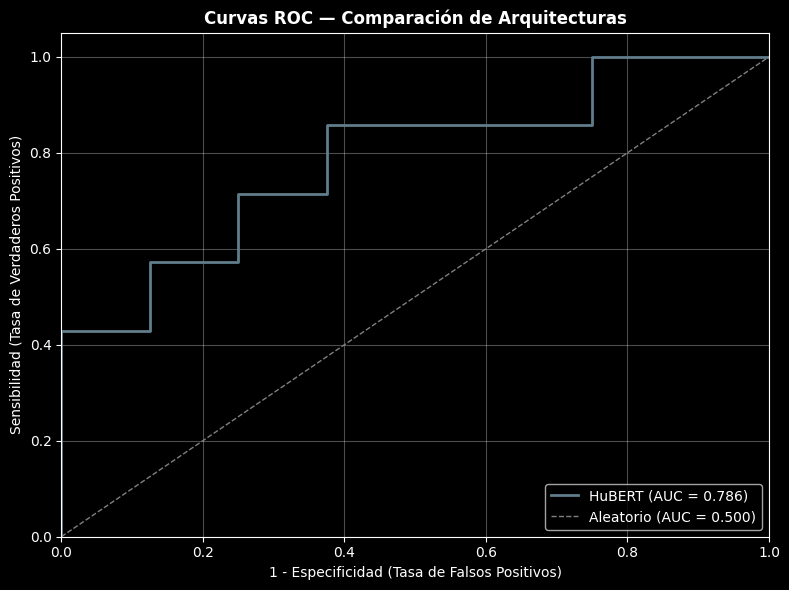

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

colors = {"CNN1D": "#2196F3", "CNN1D_Light": "#4CAF50",
          "SincNet": "#FF9800", "Wav2Vec2": "#F44336"}

for name, m in eval_results.items():
    color = colors.get(name, "#607D8B")
    ax.plot(m["fpr"], m["tpr"], color=color, linewidth=2,
            label=f"{name} (AUC = {m['AUC']:.3f})")

ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Aleatorio (AUC = 0.500)")

ax.set_xlabel("1 - Especificidad (Tasa de Falsos Positivos)")
ax.set_ylabel("Sensibilidad (Tasa de Verdaderos Positivos)")
ax.set_title("Curvas ROC — Comparación de Arquitecturas", fontweight="bold")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

## Matrices de confusión

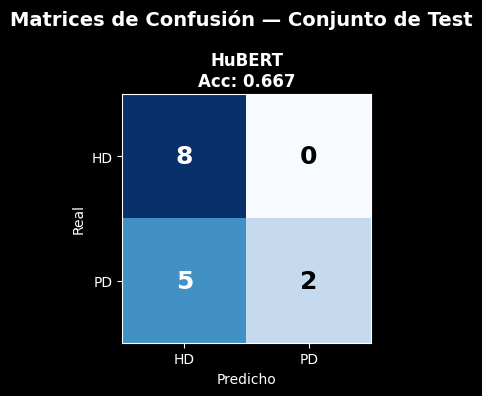

In [29]:
n_models = len(eval_results)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))

if n_models == 1:
    axes = [axes]

for ax, (name, m) in zip(axes, eval_results.items()):
    cm = np.array([[m["TN"], m["FP"]],
                   [m["FN"], m["TP"]]])

    ax.imshow(cm, cmap="Blues", aspect="equal")

    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    fontsize=18, fontweight="bold",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["HD", "PD"])
    ax.set_yticklabels(["HD", "PD"])
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    ax.set_title(f"{name}\nAcc: {m['Accuracy']:.3f}", fontweight="bold")

plt.suptitle("Matrices de Confusión — Conjunto de Test", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()